In [ ]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("sanjanasatish68l/carnatic-ragas-with-features")
print("Path to dataset files:", path)

100%|██████████| 128k/128k [00:00<00:00, 62.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sanjanasatish68l/carnatic-ragas-with-features/versions/1


In [ ]:
import pandas as pd
import os

# See what files are in the dataset
for file in os.listdir(path):
    print(file)

Dataset.csv


In [ ]:
# Load and inspect the data
df = pd.read_csv(f"/content/Dataset.csv")  # replace with actual filename
print(df.shape)
print(df.head())
print(df.columns.tolist())
print(df['raga'].value_counts())  # see which ragas are in there

(1112, 26)
   Unnamed: 0                                   filename      rmse  \
0           0  WhatsApp Ptt 2023-06-18 at 04.25.30.wav-1  0.007417   
1           1  WhatsApp Ptt 2023-06-18 at 04.25.30.wav-2  0.007417   
2           2  WhatsApp Ptt 2023-06-18 at 04.25.30.wav-3  0.007417   
3           3  WhatsApp Ptt 2023-06-18 at 04.25.30.wav-4  0.007417   
4           4  WhatsApp Ptt 2023-06-18 at 04.25.30.wav-5  0.007417   

   chroma_stft    spec_cent      spec_bw      mfcc0      mfcc1      mfcc2  \
0     0.275107  1475.713161  1355.793034 -571.81415  155.59116 -67.480750   
1     0.275107  1475.713161  1355.793034 -571.81415  155.59116 -67.480750   
2     0.229692  1383.890624  1224.570413 -480.99800  157.79916 -65.643394   
3     0.249781  1391.394982  1258.506032 -472.56644  162.38678 -68.286530   
4     0.268305  1445.604088  1292.949714 -458.65433  151.42929 -66.322430   

      mfcc3  ...     mfcc10    mfcc11    mfcc12    mfcc13    mfcc14  \
0  2.133071  ...  -6.002566  5.672

Dataset shape after filtering: (800, 26)
raga
Kapi            100
Kamas           100
Hamsanandam     100
Bhairavi        100
Jaganmohini     100
Hamsadhwani     100
Kalyani         100
Harikambhoji    100
Name: count, dtype: int64

Training samples: 640
Testing samples: 160

MODEL COMPARISON
Random Forest: 93.12%
SVM: 89.38%
KNN: 89.38%

Best Model: Random Forest (93.12%)

Detailed Report:
              precision    recall  f1-score   support

    Bhairavi       0.95      1.00      0.98        20
 Hamsadhwani       0.89      0.80      0.84        20
 Hamsanandam       0.89      0.85      0.87        20
Harikambhoji       0.95      0.90      0.92        20
 Jaganmohini       1.00      1.00      1.00        20
     Kalyani       1.00      0.95      0.97        20
       Kamas       0.83      1.00      0.91        20
        Kapi       0.95      0.95      0.95        20

    accuracy                           0.93       160
   macro avg       0.93      0.93      0.93       160
weighted a

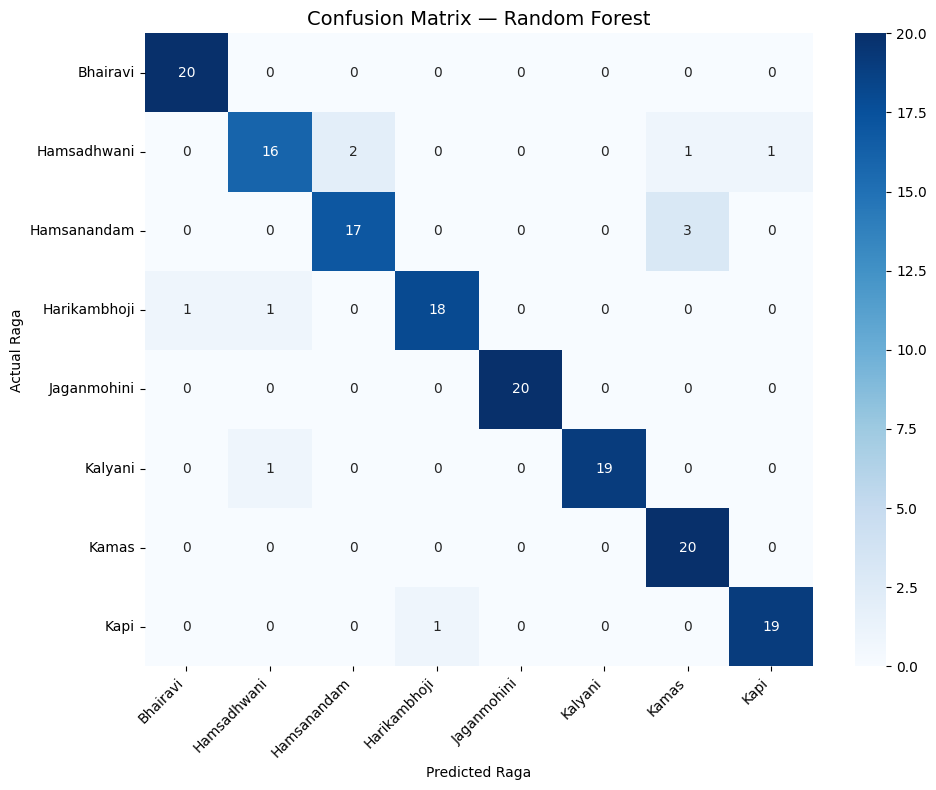

Confusion matrix saved!


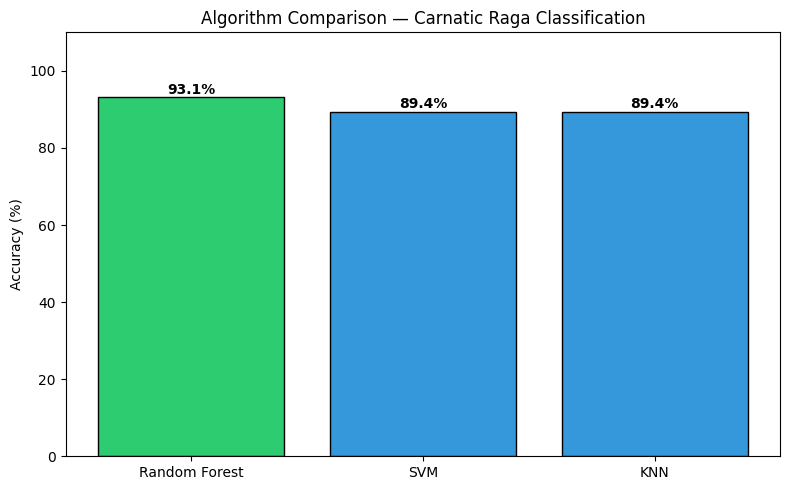

Comparison chart saved!


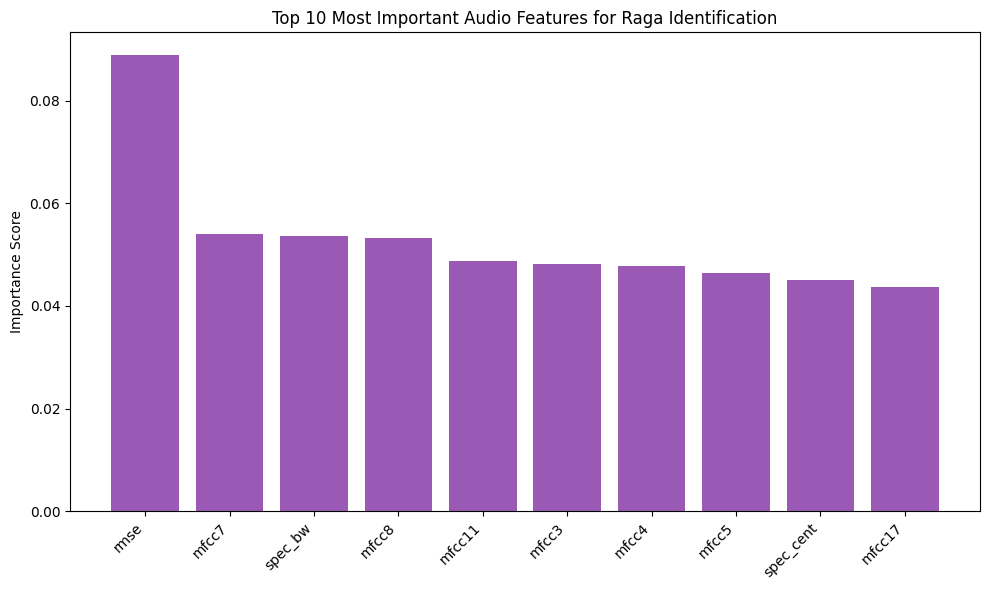

Feature importance chart saved!

Model saved! Best algorithm: Random Forest
Files saved: raga_classifier.pkl, label_encoder.pkl, scaler.pkl


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD DATA ──────────────────────────────────────────
df = pd.read_csv("/content/Dataset.csv")  # adjust filename if needed

# Keep only top 8 ragas (100 samples each — balanced)
top_ragas = ['Kapi', 'Kamas', 'Hamsanandam', 'Bhairavi',
             'Jaganmohini', 'Hamsadhwani', 'Kalyani', 'Harikambhoji']

df = df[df['raga'].isin(top_ragas)]
print(f"Dataset shape after filtering: {df.shape}")
print(df['raga'].value_counts())

# ── 2. PREPARE FEATURES ───────────────────────────────────
# Drop non-feature columns
X = df.drop(['Unnamed: 0', 'filename', 'raga'], axis=1)
y = df['raga']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale features (important for SVM and KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# ── 3. TRAIN & COMPARE 3 ALGORITHMS ──────────────────────
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM":           SVC(kernel='rbf', random_state=42),
    "KNN":           KNeighborsClassifier(n_neighbors=5)
}

results = {}

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {"model": model, "accuracy": acc, "predictions": y_pred}
    print(f"{name}: {acc*100:.2f}%")

# ── 4. BEST MODEL ─────────────────────────────────────────
best_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = results[best_name]['model']
best_preds = results[best_name]['predictions']

print(f"\nBest Model: {best_name} ({results[best_name]['accuracy']*100:.2f}%)")
print("\nDetailed Report:")
print(classification_report(y_test, best_preds, target_names=le.classes_))

# ── 5. CONFUSION MATRIX ───────────────────────────────────
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}', fontsize=14)
plt.ylabel('Actual Raga')
plt.xlabel('Predicted Raga')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved!")

# ── 6. ACCURACY COMPARISON BAR CHART ─────────────────────
plt.figure(figsize=(8, 5))
names = list(results.keys())
accs = [results[n]['accuracy']*100 for n in names]
colors = ['#2ecc71' if n == best_name else '#3498db' for n in names]
bars = plt.bar(names, accs, color=colors, edgecolor='black')
plt.ylim(0, 110)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontweight='bold')
plt.title('Algorithm Comparison — Carnatic Raga Classification')
plt.ylabel('Accuracy (%)')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Comparison chart saved!")

# ── 7. FEATURE IMPORTANCE (Random Forest only) ────────────
rf_model = results['Random Forest']['model']
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]  # top 10 features

plt.figure(figsize=(10, 6))
plt.bar(range(10), importances[indices], color='#9b59b6')
plt.xticks(range(10), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Top 10 Most Important Audio Features for Raga Identification')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Feature importance chart saved!")

# ── 8. SAVE BEST MODEL ────────────────────────────────────
joblib.dump(best_model, 'raga_classifier.pkl')
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')
print(f"\nModel saved! Best algorithm: {best_name}")
print("Files saved: raga_classifier.pkl, label_encoder.pkl, scaler.pkl")